# Preprocessing spectra

This notebook shows how to prepare the data to further analysis. 
*  load matlab file
* prepare  spectra 
* plot them

Dataset properties:
* All contacts were localized in a common stereotactic space allowing the accumulation and superposition of results from many subjects. 
* Sixty-second artefact-free sections during wakefulness were selected. 
* Power spectra were calculated for 38 brain regions, and compared to a set of channels with no spectral peaks in order to identify significant peaks in the different regions. 
* A total of 1785 channels with normal brain activity from 106 patients were identified. There were on average 2.7 channels per cm3 of cortical grey matter. The number of contacts per brain region averaged 47 (range 6–178)

* patients with refractory focal epilepsy are the only human subject  where extensive  intracranial cortical EEG studies are undertaken



In [1]:
from IPython import get_ipython 
ip = get_ipython()
ip.run_line_magic('load_ext', 'autoreload')
ip.run_line_magic('autoreload', '2')

ip.run_line_magic('load_ext', 'watermark')
ip.run_line_magic('watermark', '-a "Daniel Borek" -u -d -p mne,bycycle,fooof,pandas,numpy,pesco')

Author: Daniel Borek

Last updated: 2026-04-22

mne    : 1.12.1
bycycle: unknown
fooof  : unknown
pandas : 2.3.3
numpy  : 2.4.4
pesco  : 0.0.1.dev0



In [2]:
import numpy as np
import pandas as pd
import mne as mne

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('white')
%matplotlib inline

import sys
#sys.path.append("..")  #add folder levels above notebook

# this is custom kenel 
# print kernel name if running mne virtulenv

In [3]:
from pathlib import Path
from pesco.io import load_ieeg, load_sources
from pesco.preprocess import filter_network, get_psd_interval
from pesco.experimental.clusterization import compute_clusters, identify_small_clusters

DATA_PATH = Path("/Users/daniel/PhD/spectral-comparison/code/data/Frauscher2018/")
DATA_PATH_SOURCES = Path("/Users/daniel/PhD/spectral-comparison/code/data/Mantini2018/")
OUT_PATH = Path("/Users/daniel/PhD/spectral-comparison/code/data/preproc/")

raw, result = load_ieeg(DATA_PATH, OUT_PATH)

Creating RawArray with float64 data, n_channels=1772, n_times=13600
    Range : 0 ... 13599 =      0.000 ...    67.995 secs
Ready.
Overwriting existing file.
Writing /Users/daniel/PhD/spectral-comparison/code/data/preproc/ieeg_raw.fif
Overwriting existing file.
Closing /Users/daniel/PhD/spectral-comparison/code/data/preproc/ieeg_raw.fif
[done]


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 80 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 80.00 Hz
- Upper transition bandwidth: 20.00 Hz (-6 dB cutoff frequency: 90.00 Hz)
- Filter length: 1321 samples (6.605 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandstop filter:
- Windowed frequency-domain design (firwin2) method
- Hamming window
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 2640 samples (13.200 s)

Using matplotlib as 2D backend.


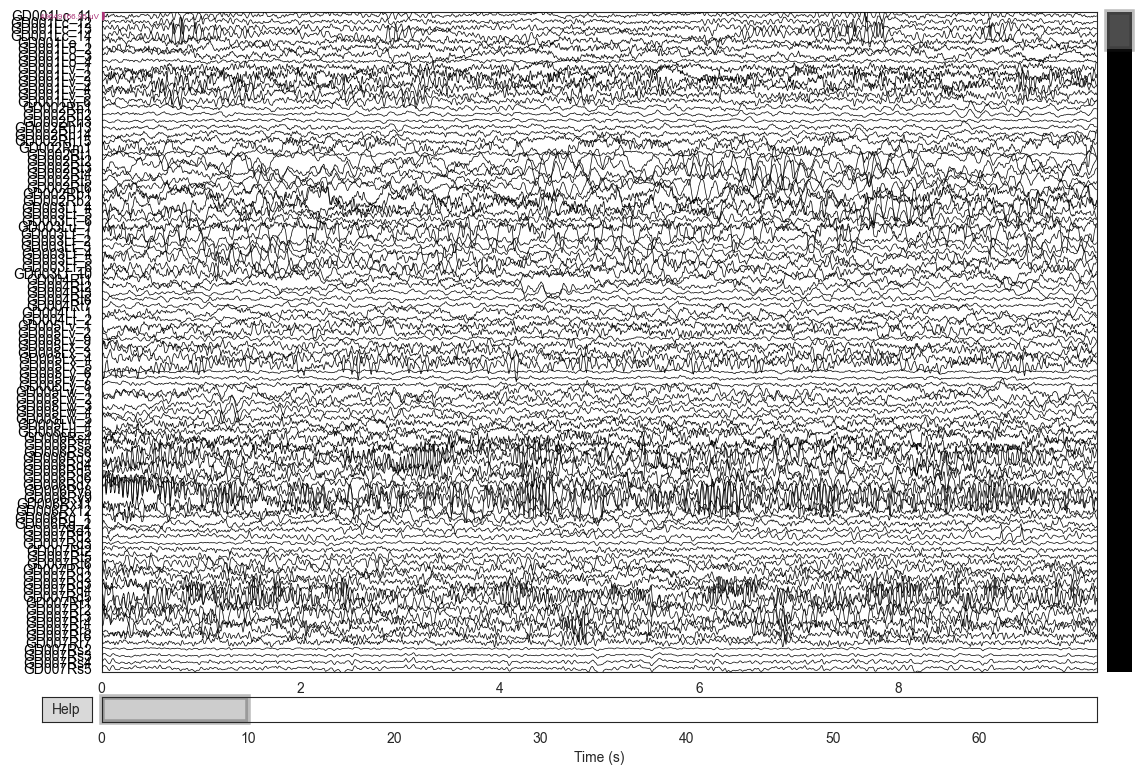

In [4]:
raw = filter_network(raw)
scalings = 'auto'  # Could also pass a dictionary with some value == 'auto'
x= raw.plot(n_channels=100, scalings=scalings, title='Auto-scaled Data from arrays',
         show=True, block=True)

Creating RawArray with float64 data, n_channels=1444, n_times=62689
    Range : 0 ... 62688 =      0.000 ...   313.440 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 80 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 80.00 Hz
- Upper transition bandwidth: 20.00 Hz (-6 dB cutoff frequency: 90.00 Hz)
- Filter length: 1321 samples (6.605 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandstop filter:
- Windowed frequency-domain design (firwin2) method
- Hamming window
- Lower transition bandwidth: 0.50 Hz


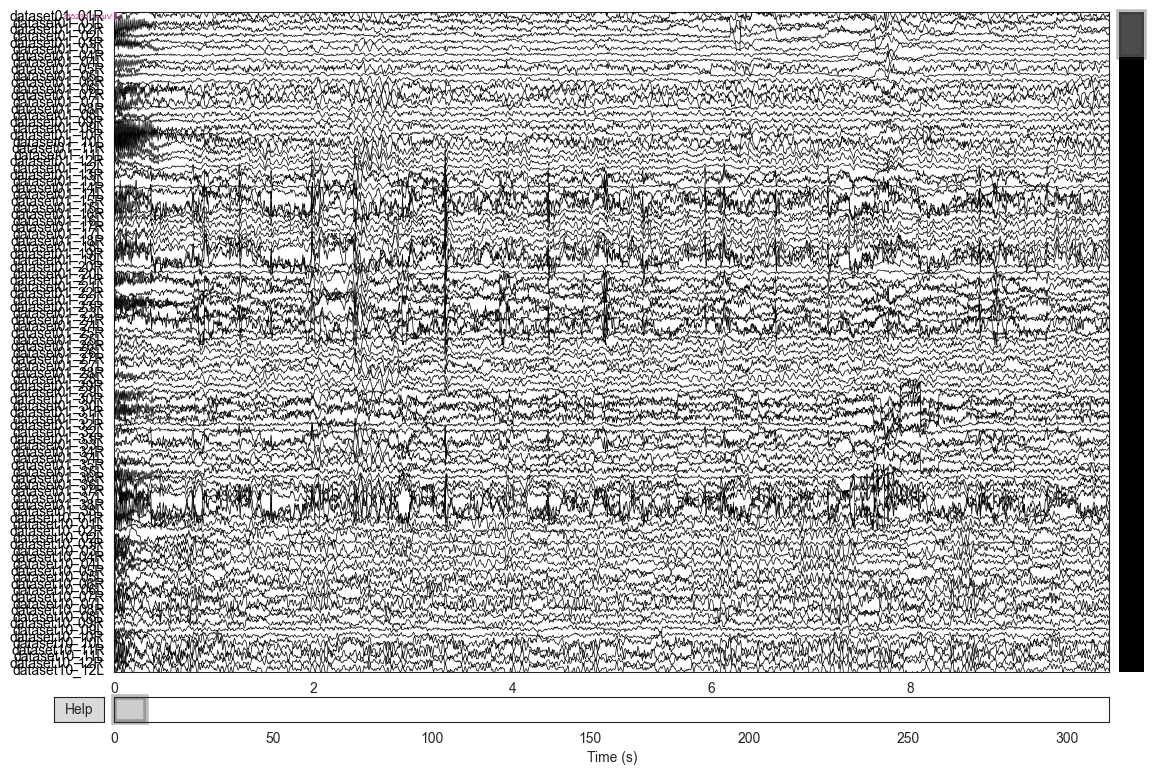

In [5]:
sources, result_src = load_sources(DATA_PATH_SOURCES)
sources = filter_network(sources)
scalings = 'auto'  # Could also pass a dictionary with some value == 'auto'
y= sources.plot(n_channels=100, scalings=scalings, title='Auto-scaled Data from arrays',
         show=True, block=True)

 ### Plot the preprepocessed spectra of the signal 

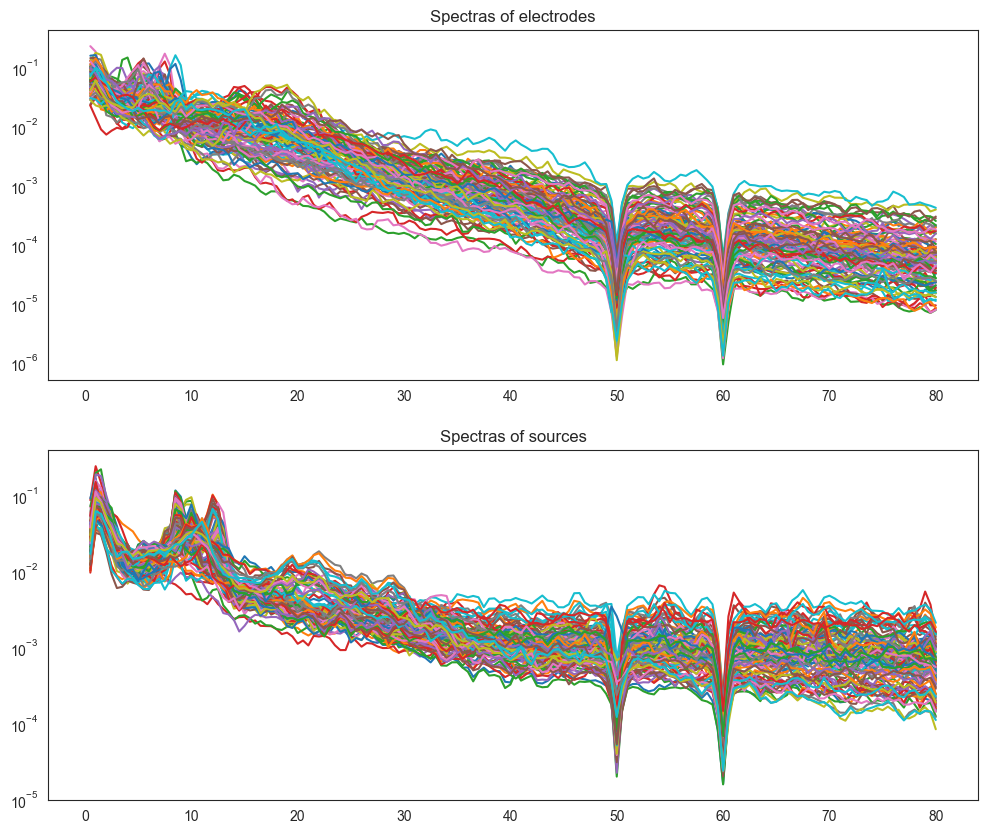

In [6]:
plt.figure(figsize=(12, 10))
plt.subplot(211)
psd_df, frequency_bins = get_psd_interval(raw)

for i in range(0,100):
    plt.plot(frequency_bins, psd_df.values[i,:])
    plt.yscale('log')
plt.title('Spectras of electrodes')


src_df, frequency_bins = get_psd_interval(sources)
plt.subplot(212)

for i in range(0,100):
    plt.plot(frequency_bins, src_df.values[i,:])
    plt.yscale('log')
plt.title('Spectras of sources')
plt.show()

# Plot clusterization result

In [7]:
how_many_clusters = 10
src_label = compute_clusters(src_df, HowManyClusters=how_many_clusters, random_seed=None)
medians = src_label.groupby('clusters').median()

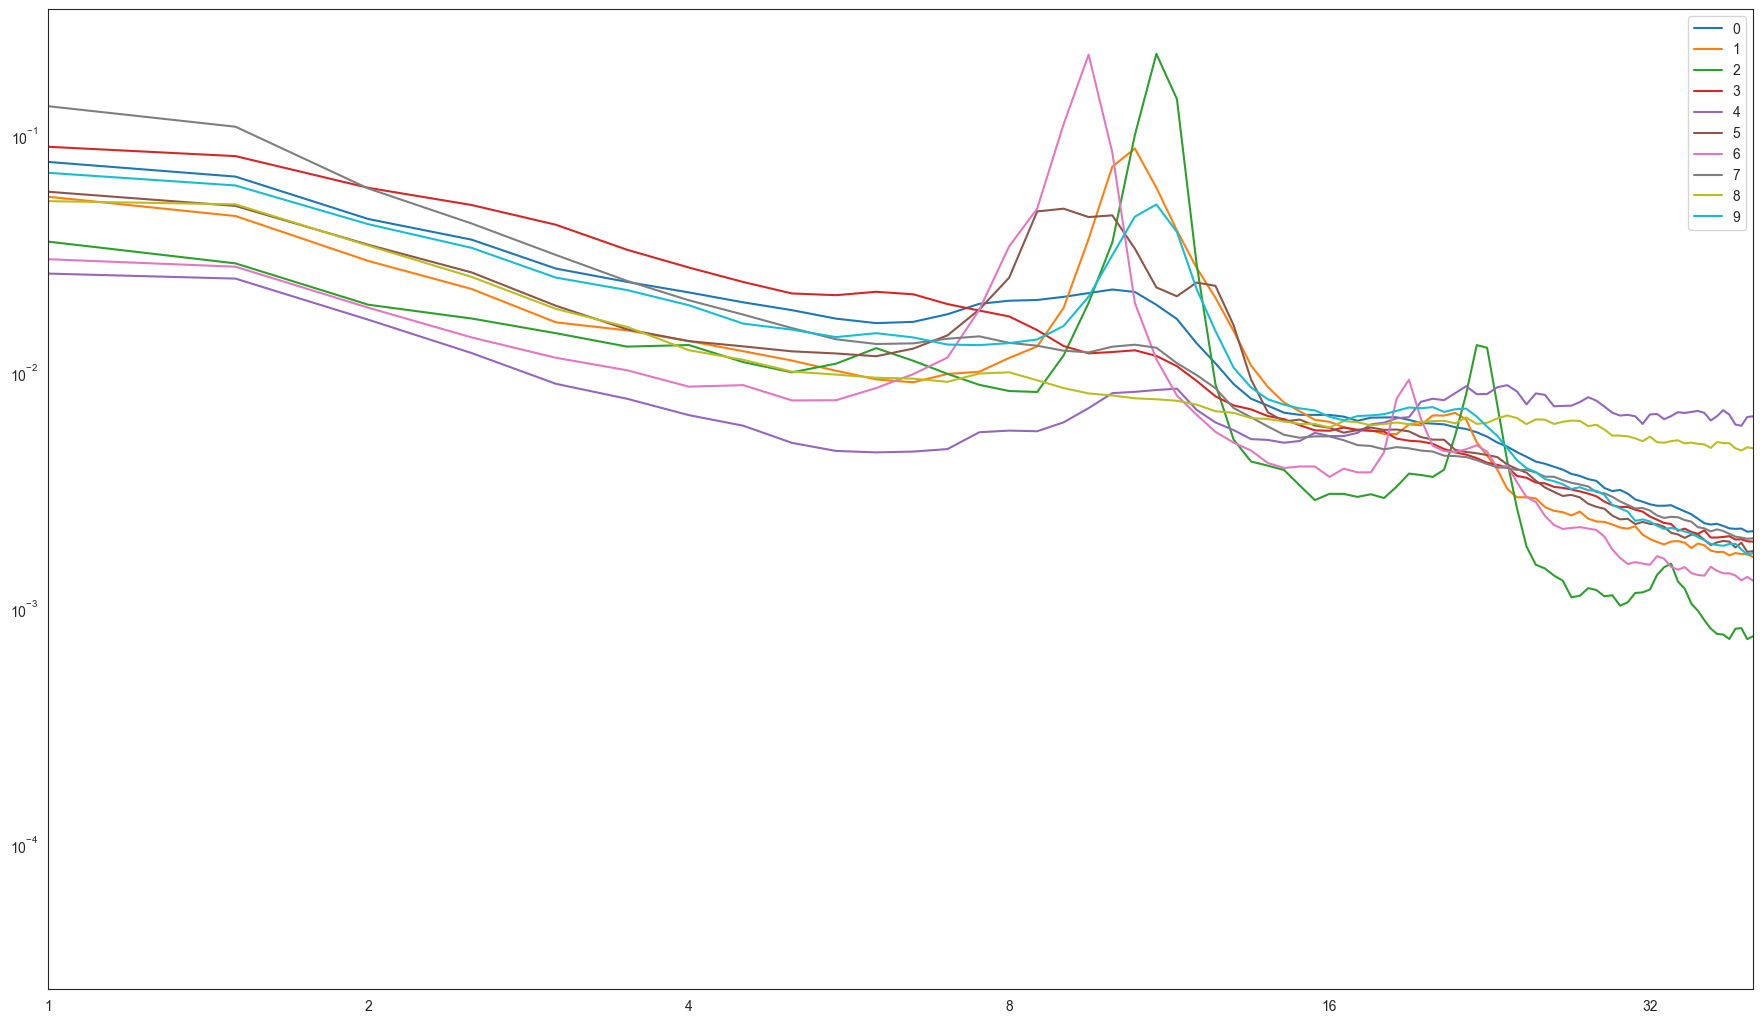

In [8]:
plt.figure(figsize=(22, 28))
plt.subplot(211)
for k in range(0, how_many_clusters):
    mean_cluster_spectrum = src_df[src_label['clusters']==k].mean()
    plt.plot(frequency_bins, mean_cluster_spectrum)
    plt.legend(range(0,how_many_clusters))
    plt.yscale('log')
    plt.xscale('log')

    plt.xlim(1, 40)
    xticks = [1, 2, 4, 8, 16, 32]
    ticklabels = ['1', '2', '4', '8', '16', '32']
    plt.xticks(xticks, ticklabels)
plt.show()

In [9]:
how_many_clusters = 10
psd_label = compute_clusters(psd_df, HowManyClusters=how_many_clusters, random_seed=None)
medians = psd_label.groupby('clusters').median()

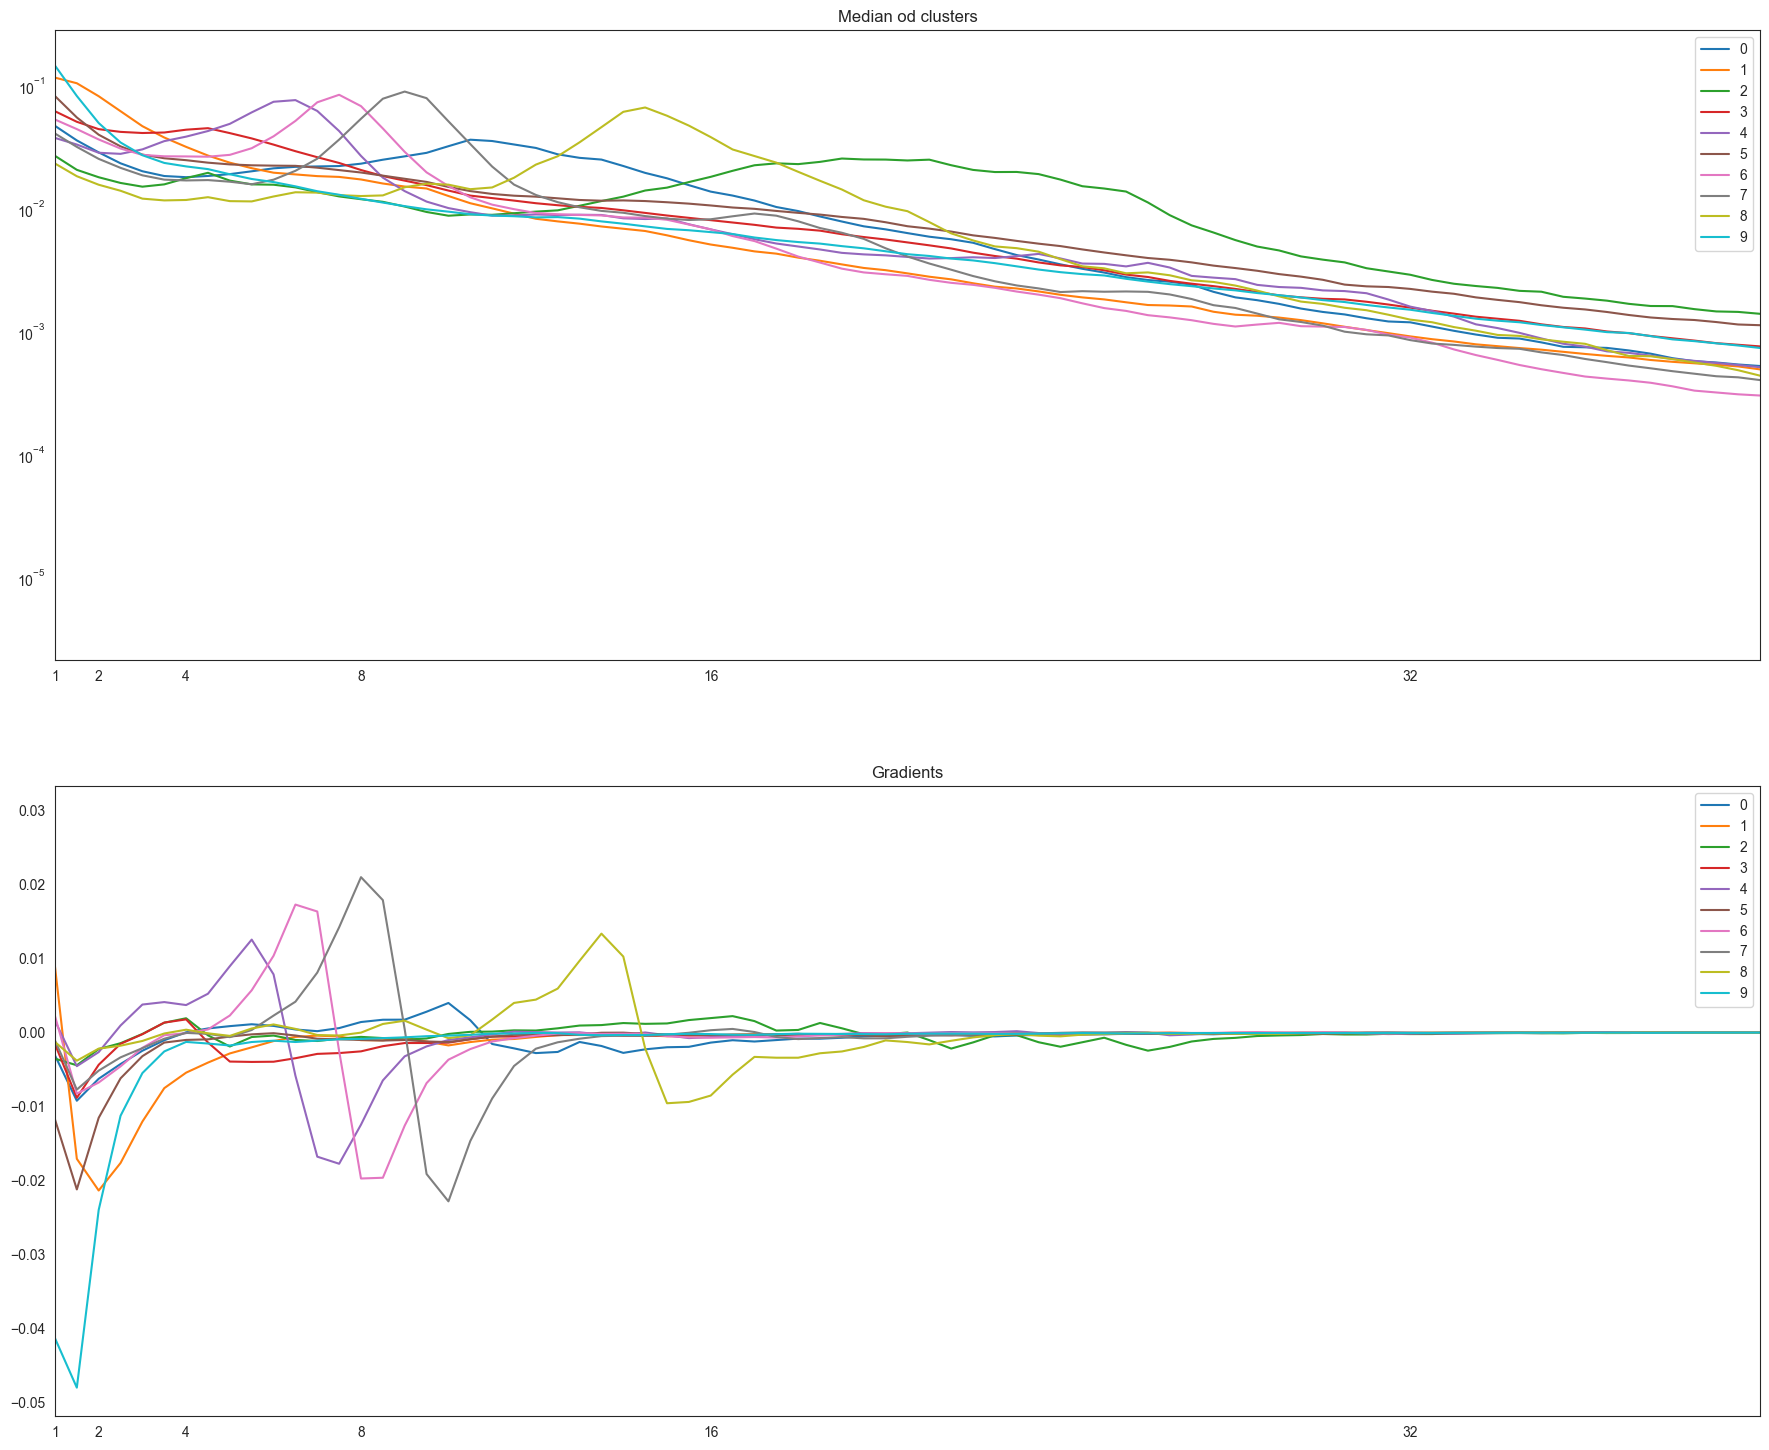

In [10]:
plt.figure(figsize=(22, 18))
plt.subplot(211)
for k in range(0, how_many_clusters):
    mean_cluster_spectrum = psd_df[psd_label['clusters']==k].mean()
    plt.plot(frequency_bins, mean_cluster_spectrum)
    plt.legend(range(0,how_many_clusters))
    plt.yscale('log')

    plt.xlim(1, 40)
    xticks = [1, 2, 4, 8, 16, 32]
    ticklabels = ['1', '2', '4', '8', '16', '32']
    plt.xticks(xticks, ticklabels)
plt.title('Median od clusters')

plt.subplot(212)
for k in range(0, how_many_clusters):
    mean_cluster_spectrum = psd_df[psd_label['clusters']==k].mean()
    gradient = np.gradient(mean_cluster_spectrum)
    plt.plot(frequency_bins, gradient)
    plt.legend(range(0,how_many_clusters))

    plt.xlim(1, 40)
    xticks = [1, 2, 4, 8, 16, 32]
    ticklabels = ['1', '2', '4', '8', '16', '32']
    plt.xticks(xticks, ticklabels)
plt.title('Gradients')

plt.show()

# Rand index 
Rand index  R is a measure of the similarity between two data clusterings. It  is calculated by the formula

$R = \frac{a + b}{{n}\choose{2}} $

The $a$ in the formula refers to the number of   pairs of elements belonging to a same cluster across two different clustering results and the $b$ refers to the number of  pairs of elements  in different clusters across two different clustering results. The denominator is a binomial coefficient. ${n}\choose{2}$ is the number of unordered pairs in a set of n elements. For example, if you have set of 4 elements {a, b, c, d}, there are 6 unordered pairs: {a, b}, {a, c}, {a, d}, {b, c}, {b, d}, and {c, d}. 

 Adjusted Rand index (ARI), is the corrected-for-chance (number of clusters) version of the Rand index. More to read [here](https://davetang.org/muse/2017/09/21/adjusted-rand-index/).

In [18]:
smal = identify_small_clusters(medians)
print(smal)

[]
